In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import auc, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, precision_recall_curve

/project/zhiwei/cq5/miniconda3/envs/Protein/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[512, 512, 512, 256, 256, 256], dropout=0.2):
        super(MLP, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_sizes = hidden_sizes
        self.dropout = dropout
        
        layers = []
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.BatchNorm1d(hidden_sizes[0]))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        
        for i in range(len(hidden_sizes) - 1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(nn.BatchNorm1d(hidden_sizes[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        
        layers.append(nn.Linear(hidden_sizes[-1], output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [3]:
device = "cuda:0"

In [12]:
def load_data(dataset_index):
    print(f"Processing dataset {dataset_index}...")
    # base_path = '/project/zhiwei/hf78/vibtcr/data/new_split/pep+cdr3b/'
    # embed_base_path = '/project/zhiwei/hf78/vibtcr/data/embedNA/val/' 
    base_path = "/scratch/zhiwei/hf78/TCRproject/vibtcr/data/new_split/pep+cdr3b"
    embed_base_path = "/scratch/zhiwei/hf78/TCRproject/vibtcr/data/embedNA/val"
        
    #df_train = pd.read_csv(f'/project/zhiwei/hf78/TEINet-master/data/tchard/val/train-tmp/NAvaltrain-{dataset_index}.csv', low_memory=False)
    #df_train = pd.read_csv(f'{base_path}/trainpos/NAdrop3/train-{dataset_index}.csv', low_memory=False)
    df_train = pd.read_csv(f'{base_path}/train/only-neg-assays/train-{dataset_index}.csv', low_memory=False)
    df_val = pd.read_csv(f'{base_path}/validation/only-neg-assays/validation-{dataset_index}.csv', low_memory=False)
    df_test = pd.read_csv(f'{base_path}/test/only-neg-assays/test-{dataset_index}.csv', low_memory=False)
    #df_val = pd.read_csv(f'{base_path}/validation/NA_val_{dataset_index}.csv', low_memory=False)
    #df_test = pd.read_csv(f'{base_path}/test/NA_test_{dataset_index}.csv', low_memory=False)
    
    #train_pep_mol = np.load(f'{embed_base_path}/train{dataset_index}_pep_mol.npy')
    #train_pep_mol = np.load(f'/project/zhiwei/hf78/TEINet-master/data/tchard/val/trainpos/NAdrop3/train{dataset_index}_pep_mol.npy')
    train_pep_mol = np.load(f'{embed_base_path}/train{dataset_index}_pep_mol.npy')
    val_pep_mol = np.load(f'{embed_base_path}/val{dataset_index}_pep_mol.npy')
    test_pep_mol = np.load(f'{embed_base_path}/test{dataset_index}_pep_mol.npy')
    
    #train_cdr3 = np.load(f'/project/zhiwei/hf78/TEINet-master/data/tchard/embedNAtmp/trainonly{dataset_index}_CDR3_esm.npy')
    #train_cdr3 = np.load(f'/project/zhiwei/hf78/TEINet-master/data/tchard/embedNA/trainonly{dataset_index}_CDR3_esm.npy')
    train_cdr3 = np.load(f'{embed_base_path}/train{dataset_index}_CDR3_esm.npy')
    val_cdr3 = np.load(f'{embed_base_path}/val{dataset_index}_CDR3_esm.npy')
    test_cdr3 = np.load(f'{embed_base_path}/test{dataset_index}_CDR3_esm.npy')

    X_train = np.column_stack((train_pep_mol, train_cdr3))
    X_val = np.column_stack((val_pep_mol, val_cdr3))
    X_test = np.column_stack((test_pep_mol, test_cdr3))

    y_train = df_train['label']
    y_val = df_val['label']
    y_test = df_test['label']
    
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [13]:
def get_diff_seen_ratio(seen_ratio = 0):
    
    num_rows_to_replace = int(np.ceil(X_test.shape[0] * seen_ratio))
    rows_to_replace = np.random.choice(X_test.shape[0], size = num_rows_to_replace, replace=False)
    rows_to_place = np.random.choice(X_train.shape[0], size = num_rows_to_replace, replace=False)

    X_new_test = X_test.copy()
    X_new_test[rows_to_replace, :] = X_new_train[rows_to_place, :]

    y_new_test = y_test.copy()
    y_new_test[rows_to_replace] = y_new_train[rows_to_place]


    return X_new_test, y_new_test

In [14]:
def get_result(seen_ratio = 0):

    X_new_test, y_new_test = get_diff_seen_ratio(seen_ratio)
    y_new_pred = model(torch.from_numpy(X_new_test).to(device))
    test_probabilities = torch.softmax(y_new_pred, dim=1)[:, 1].detach().cpu().numpy()
    test_predictions = [1 if prob > 0.5 else 0 for prob in test_probabilities]
    test_auc = roc_auc_score(y_new_test, test_probabilities)
    precision, recall, _ = precision_recall_curve(y_new_test, test_probabilities)

    metrics = {
            'AUROC': test_auc,
            'Accuracy': accuracy_score(y_new_test, test_predictions),
            'Recall': recall_score(y_new_test, test_predictions),
            'Precision': precision_score(y_new_test, test_predictions),
            'F1 score': f1_score(y_new_test, test_predictions),
            'AUPR': auc(recall, precision),
        }

    result_df = pd.DataFrame({
            'score': list(metrics.values()),
            'metrics': list(metrics.keys()),
            'experiment': [dataset_index] * len(metrics)
        })
    
    return result_df

In [16]:
seen_ratio_list = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
auc_roc_list = []

for dataset_index in range(5):
    auc_roc_list.append([])
    model_path = f"/project/zhiwei/sj225/TC_Hard/results/HF_ME/NA/1/best_mol-esm_{dataset_index}.pth"

    X_train, y_train, X_val, y_val, X_test, y_test = load_data(dataset_index)

    model = MLP(X_train.shape[1], 2, [256], dropout=0.2).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    X_new_train = np.vstack([X_train, X_val])
    y_new_train = np.hstack([y_train, y_val])
    X_new_train.shape, y_new_train.shape, X_test.shape, y_test.shape

    for seen_ratio in seen_ratio_list:
        result_df = get_result(seen_ratio)
        auc_roc_list[dataset_index].append(result_df.iloc[0]["score"])

auc_roc_list = np.array(auc_roc_list)

mean_auc_roc = auc_roc_list.mean(axis = 0)
print(mean_auc_roc)


Processing dataset 0...
Processing dataset 1...
Processing dataset 2...
Processing dataset 3...
Processing dataset 4...
[0.86082924 0.96964396 0.97719351 0.9755022  0.96772089 0.95306837]


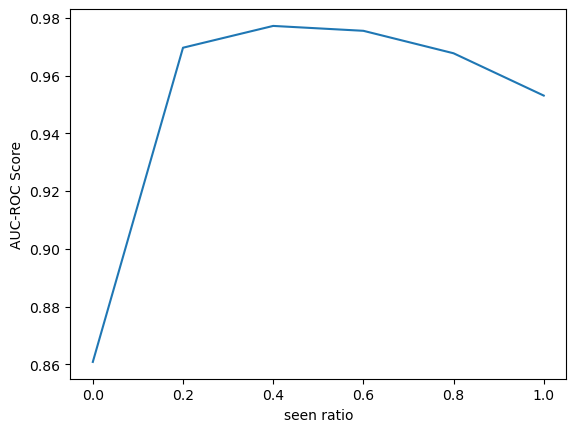

In [18]:
plt.xlabel("seen ratio")
plt.ylabel("AUC-ROC Score")
plt.plot(seen_ratio_list, mean_auc_roc)